In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv('tabela_seca_agricultura.csv')

print(df.shape)
df.head(20)

Saving tabela_seca_agricultura.csv to tabela_seca_agricultura.csv
(54, 4)


,Comunidad,Ano,Volume_Agua_Agricola,Volume_Agua_hm3
0,Andalucía,2000,10220872,260.269231
1,Andalucía,2001,10284300,238.038462
2,Andalucía,2002,10606274,172.557692
3,Andalucía,2003,10422520,232.307692
4,Andalucía,2004,9702112,190.288462
5,Andalucía,2005,8931278,155.211538
6,Andalucía,2006,8411436,174.865385
7,Andalucía,2007,7909308,200.269231
8,Andalucía,2008,7631330,306.153846
9,Andalucía,2009,8343798,565.384615


In [ ]:
df.isnull().sum()

,0
Comunidad,0
Ano,0
Volume_Agua_Agricola,0
Volume_Agua_hm3,0


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Comunidad'], drop_first=True)
df_encoded.shape

y = df_encoded['Volume_Agua_hm3']

# Aqui está o ajuste! Removendo a variável alvo e a variável temporal juntas:
X = df_encoded.drop(['Volume_Agua_hm3', 'Ano'], axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor

# 1. Criar e treinar o modelo Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# 2. Extrair a importância das variáveis
importancias = modelo_rf.feature_importances_

# 3. Criar um DataFrame organizado com os resultados
df_importancia = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': importancias
})

# 4. Ordenar do maior peso para o menor
df_importancia = df_importancia.sort_values(by='Importância', ascending=False)

# 5. Salvar o arquivo para atualizar no Power BI
df_importancia.to_csv('importancia_rf_corrigida.csv', index=False)

# Exibir na tela do Python para você já ver o resultado!
print(df_importancia)
print(X_train.shape, X_test.shape)

                         Variável  Importância
0            Volume_Agua_Agricola     0.973313
1  Comunidad_Comunitat Valenciana     0.018435
2      Comunidad_Región de Murcia     0.008252
(43, 3) (11, 3)


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred_lr)
print(r2)

0.2339578263488553


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, pred_rf)
print(r2_rf)

0.9642761637629359


In [ ]:
Q1 = df['Volume_Agua_hm3'].quantile(0.25)
Q3 = df['Volume_Agua_hm3'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
df_sem_outliers = df[(df['Volume_Agua_hm3'] >= limite_inferior) & (df['Volume_Agua_hm3'] <= limite_superior)]
print(df.shape, df_sem_outliers.shape)

(54, 4) (54, 4)


In [ ]:
df_encoded2 = pd.get_dummies(df_sem_outliers, columns=['Comunidad'], drop_first=True)
print("Novo formato:", df_encoded2.shape)

y2 = df_encoded2['Volume_Agua_hm3']
X2 = df_encoded2.drop('Volume_Agua_hm3', axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
print("Treino e Teste:", X_train2.shape, X_test2.shape)

lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)
pred_lr2 = lr2.predict(X_test2)
r2_lr2 = r2_score(y_test2, pred_lr2)
print("Regresión Lineal (sin outliers):", r2_lr2)

rf2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf2.fit(X_train2, y_train2)
pred_rf2 = rf2.predict(X_test2)
r2_rf2 = r2_score(y_test2, pred_rf2)
print("Random Forest (sin outliers):", r2_rf2)

Novo formato: (54, 5)
Treino e Teste: (43, 4) (11, 4)
Regresión Lineal (sin outliers): 0.2339578263488553
Random Forest (sin outliers): 0.9642761637629359


In [ ]:
rf2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf2.fit(X_train2, y_train2)
pred_rf2 = rf2.predict(X_test2)
r2_rf2 = r2_score(y_test2, pred_rf2)
print("Random Forest (sin outliers):", r2_rf2)

Random Forest (sin outliers): 0.9642761637629359


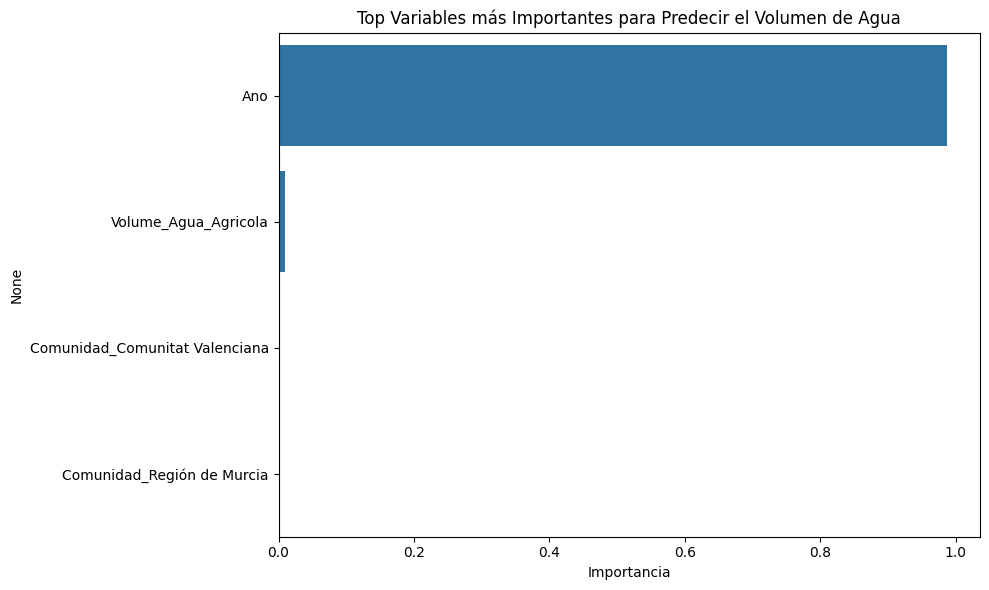

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
importancias = pd.Series(rf2.feature_importances_, index=X2.columns)
top15 = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top15.values, y=top15.index)
plt.title('Top Variables más Importantes para Predecir el Volumen de Agua')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

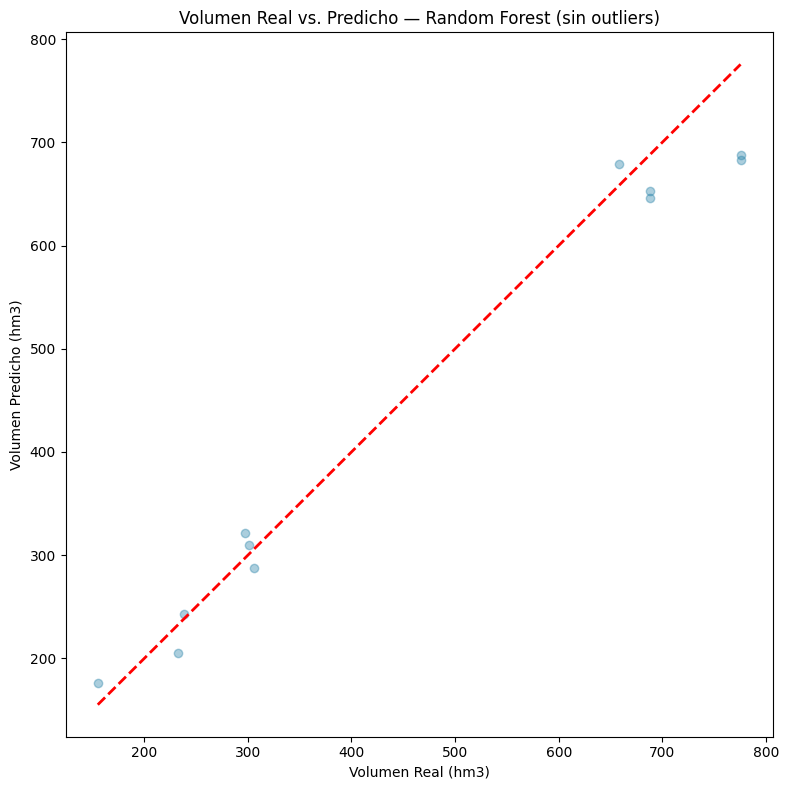

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test2, pred_rf2, alpha=0.4, color='#2E86AB')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--', lw=2)

plt.xlabel('Volumen Real (hm3)')
plt.ylabel('Volumen Predicho (hm3)')
plt.title('Volumen Real vs. Predicho — Random Forest (sin outliers)')

plt.tight_layout()
plt.savefig('real_vs_predicho.png', dpi=150)
plt.show()

In [ ]:
df_sem_outliers.to_csv('base_hidrica_final_limpa.csv', index=False)
files.download('base_hidrica_final_limpa.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# 1. Pega os pesos corretos do modelo da água (rf) e junta com o nome das colunas
importancias_agua = pd.Series(rf.feature_importances_, index=X_train.columns)

# 2. Transforma isso num DataFrame (tabela) e limpa os nomes
df_importancia = importancias_agua.reset_index()
df_importancia.columns = ['Variavel', 'Peso_Importancia']

# 3. Ordena do maior peso para o menor
df_importancia = df_importancia.sort_values(by='Peso_Importancia', ascending=False)

# 4. Exporta para CSV (É esse arquivo que vai para o Power BI!)
df_importancia.to_csv('tabela_importancia_variaveis.csv', index=False)

print("Tabela exportada com sucesso! Faça o download do CSV.")
df_importancia.head()

from google.colab import files
files.download('tabela_importancia_variaveis.csv')

Tabela exportada com sucesso! Faça o download do CSV.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# 1. Cria a tabela juntando o valor real (y_test) e o valor que a IA calculou (pred_rf)
df_predicoes = pd.DataFrame({
    'Volume_Real_hm3': y_test,
    'Volume_Predito_hm3': pred_rf
})

# 2. Recupera o "Ano" e a "Comunidad" originais para sabermos de quando é cada previsão
df_predicoes['Ano'] = df.loc[X_test.index, 'Ano']
df_predicoes['Comunidad'] = df.loc[X_test.index, 'Comunidad']

# 3. Exporta para CSV
df_predicoes.to_csv('tabela_predicoes_rf.csv', index=False)

# 4. Força o download automático para o seu computador
files.download('tabela_predicoes_rf.csv')

print("Tabela de predições baixada com sucesso!")
df_predicoes.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tabela de predições baixada com sucesso!


,Volume_Real_hm3,Volume_Predito_hm3,Ano,Comunidad
19,238.038462,243.286058,2001,Comunitat Valenciana
49,775.480769,687.588269,2013,Región de Murcia
48,687.788462,652.471635,2012,Región de Murcia
12,687.788462,646.201538,2012,Andalucía
44,306.153846,287.999615,2008,Región de Murcia


In [ ]:
from google.colab import files
files.download('tabela_importancia_variaveis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>